# Toxic Comments Classification - BiLSTM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JigsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: BiLSTM

Preprocessing techniques used:
* Convert text to lowercase
* Lemmatization
* Stemming
* Tokenization (accept all kind of tokens except spaces (returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import sys
sys.getrecursionlimit()

In [2]:
sys.setrecursionlimit(5000)
sys.getrecursionlimit()

5000

In [3]:
import pandas as pd
import numpy as np
import pickle, time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, recall_score, f1_score, precision_score
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.preprocessing import StandardScaler
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dense, Input, Dropout
from keras import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import text
import re
from nltk.corpus import stopwords
from datetime_extractor import DateTimeExtractor
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize,pos_tag
from nltk.stem import PorterStemmer

from tensorflow.keras.layers import Dense, Embedding,GlobalMaxPooling1D, GlobalMaxPool1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical

import seaborn as sns
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [4]:
# Load training data
df = pd.read_csv('../../Data/train_set3.csv')
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,BREAKING: Many leading Chinese scientists are ...,0.0
1,1244980592615116800,"If China can kill us, they can kill you too @A...",1.0
2,1244899032771604480,Fuck u Chi Na!!! Karma is coming soon !!! The ...,1.0
3,1244895530720710656,Some Chinese are horrible as fuck! #ChinaLiedP...,1.0
4,1244341105879142407,"@ScottGottliebMD you are a ""doctor"" and you be...",1.0


In [5]:
# Load testing data
test = pd.read_csv('../../Data/test_set3.csv')
test.head()

,Tweet ID,Text,tox
0,1230469201325895691,@BangizweNkosi @alfred_cabonena #Commies the s...,1.0
1,1245286806330806273,@LeeooZeng @ChinaDaily Mother Fucking #chinese...,1.0
2,1245502582593912833,@argyleumbrella @business Yep. Fucking MONTHS ...,1.0
3,1230388499792220163,To all the Xbots that couldn’t control your fa...,0.0
4,1241063784501915648,@realDonaldTrump This is the most racist and u...,0.0


# 3. Preprocessing

In [6]:
wordnet = WordNetLemmatizer() # Initialize wordnet lemmatizer

def lemmatize_token (text):
    s = []

    for token,tag in pos_tag(word_tokenize(text)): # tokenize text
        pos=tag[0].lower()
        
        # check token's POS tag
        if pos not in ['a', 'r', 'v', 's']:
            pos='n'
    
        s.append(wordnet.lemmatize(token,pos)) # Lemmatize list of words with pos tag
    
    sentence = (" ").join(s) # join lemmatized word
    return sentence

In [7]:
stemmer = PorterStemmer()

def stemming_token (comment):     
    for word in comment.split():
        comment = comment.replace(word, stemmer.stem(word)) # Converting words to their root forms
    return comment

In [8]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    lem_comment = lemmatize_token (comment) # lemmatize comment    
    stem_comment = stemming_token (lem_comment) # stemming comment
    
    return stem_comment

In [9]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:clean_text(word))
test['Text'] = test['Text'].map(lambda word:clean_text(word))

In [10]:
x_train, x_val, y_train, y_val = train_test_split(df['Text'], df['tox'], test_size=0.15, random_state=42)

In [11]:
#Check shape of train data
print(x_train.shape)
print(y_train.shape)

(1788,)
(1788,)


In [12]:
#Check shape of validation data
print(x_val.shape)
print(y_val.shape)

(316,)
(316,)


In [13]:
x_test = test['Text']
y_test = test['tox']

#Check shape of data
print(x_test.shape)
print(y_test.shape)

(527,)
(527,)


### Vectorize texts

In [14]:
# Create vocabulary with training texts.
tokenizer = text.Tokenizer(num_words=20000, filters='\r\t\n', lower=False)  # Limit on the number of features. We use the top 20K features.
tokenizer.fit_on_texts(list(x_train)+ list(x_val) + list(x_test))

# Vectorize training texts.
tokenized_train = tokenizer.texts_to_sequences(x_train)
tokenized_val = tokenizer.texts_to_sequences(x_val)
tokenized_test = tokenizer.texts_to_sequences(x_test)

In [15]:
# Limit on the length of text sequences. Sequences longer than this
# will be truncated.
MAX_SEQUENCE_LENGTH = 100


# Get max sequence length.
max_length = len(max(x_train, key=len))
if max_length > MAX_SEQUENCE_LENGTH:
       max_length = MAX_SEQUENCE_LENGTH

In [16]:
# Fix sequence length to max value. Sequences shorter than the length are
# padded in the end and sequences longer are truncated
# at the end.
X_train = pad_sequences(tokenized_train, maxlen=max_length, padding= 'post')
X_val = pad_sequences(tokenized_val, maxlen=max_length, padding= 'post')
X_test = pad_sequences(tokenized_test, maxlen=max_length, padding= 'post')

In [17]:
# Get length of corpus's word index
vocab_size=(len(tokenizer.word_index)+1)
print(vocab_size)

7662


###  converts a class vector (integers) to binary class matrix.

In [18]:
# converts a class vector (integers) to binary class matrix.
Y_train=to_categorical(y_train)
#Check shape of data
Y_train.shape

(1788, 2)

In [19]:
# converts a class vector (integers) to binary class matrix.
Y_val=to_categorical(y_val)
#Check shape of data
Y_val.shape

(316, 2)

In [20]:
# converts a class vector (integers) to binary class matrix.
Y_test=to_categorical(y_test)
#Check shape of data
Y_test.shape

(527, 2)

In [21]:
Y_val[:2]

array([[0., 1.],
       [0., 1.]], dtype=float32)

In [22]:
Y_test[:2]

array([[0., 1.],
       [0., 1.]], dtype=float32)

In [23]:
Y_train[:2]

array([[1., 0.],
       [0., 1.]], dtype=float32)

# 3. Create model

In [24]:
EMBEDDING_DIM=400

def model_to_optimize(optimizer='RMSprop'): #learning_rate = 0.001 default value
         
    model = Sequential()
    
    seq = Input(shape=(max_length,))
    input_seq = Embedding(
        input_dim = vocab_size, input_length = max_length,output_dim = EMBEDDING_DIM)(seq)
    
    layer = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(input_seq)
    layer = GlobalMaxPool1D()(layer)
    output = Dense(2, activation='softmax')(layer) 
        
    model = Model(inputs=seq, outputs=output)
        
    model.compile(loss='binary_crossentropy',optimizer=optimizer, metrics=['accuracy'])
    return model

In [25]:
from keras import backend, Model

model_used = model_to_optimize()
# summarize model
model_used.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 100, 400)          3064800   
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 128)          238080    
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 2)                 258       
Total params: 3,303,138
Trainable params: 3,303,138
Non-trainable params: 0
_________________________________________________________________


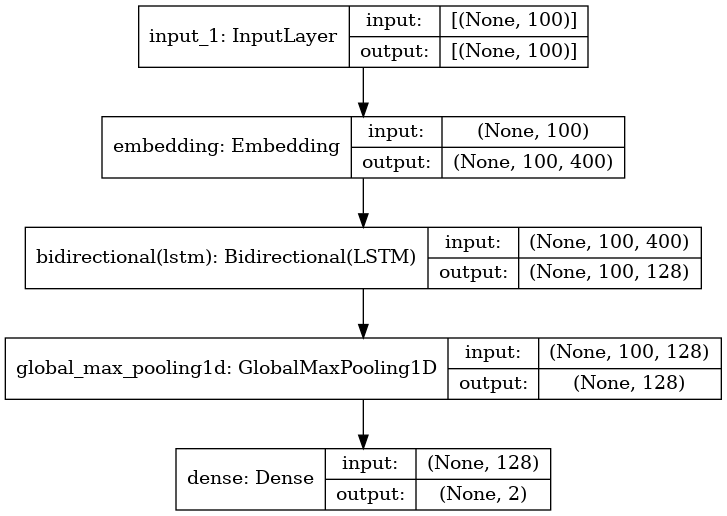

In [26]:
# plot model
plot_model(model_used, show_shapes=True)

In [27]:
## Define your callbacks
Modle_Checkpoint = ModelCheckpoint(
    'models/bilstm_approach#22.h5',
    monitor='val_loss',
    save_best_only='True',
    mode='min',
    verbose=1
)

Early_Stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=1,
    restore_best_weights='True',
    min_delta=0
)

In [28]:
callbacks = [Early_Stopping, Modle_Checkpoint, ]

### Train classifier

In [29]:
history = model_used.fit(X_train,Y_train, epochs=100,
                            callbacks=callbacks,
                            batch_size=128, #litterature review
                            validation_data=(X_val, Y_val),
                            verbose=True)

Epoch 1/100
14/14 [==============================] - 19s 1s/step - loss: 0.6694 - accuracy: 0.6202 - val_loss: 0.5845 - val_accuracy: 0.8038

Epoch 00001: val_loss improved from inf to 0.58454, saving model to models/bilstm_approach#22.h5
Epoch 2/100
14/14 [==============================] - 14s 1s/step - loss: 0.4736 - accuracy: 0.8171 - val_loss: 0.4314 - val_accuracy: 0.7816

Epoch 00002: val_loss improved from 0.58454 to 0.43138, saving model to models/bilstm_approach#22.h5
Epoch 3/100
14/14 [==============================] - 14s 975ms/step - loss: 0.2585 - accuracy: 0.9094 - val_loss: 0.3233 - val_accuracy: 0.8544

Epoch 00003: val_loss improved from 0.43138 to 0.32325, saving model to models/bilstm_approach#22.h5
Epoch 4/100
14/14 [==============================] - 14s 979ms/step - loss: 0.1451 - accuracy: 0.9497 - val_loss: 0.2642 - val_accuracy: 0.8956

Epoch 00004: val_loss improved from 0.32325 to 0.26423, saving model to models/bilstm_approach#22.h5
Epoch 5/100
14/14 [=======

### Evaluate metrics

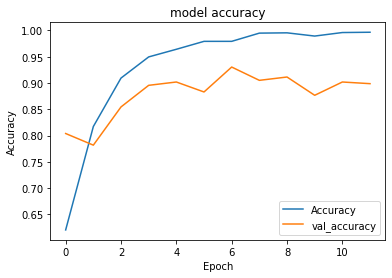

In [30]:
import matplotlib.pyplot as plt
hist = history.history
plt.plot(hist["accuracy"])
plt.plot(hist['val_accuracy'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","val_accuracy"])
plt.show()

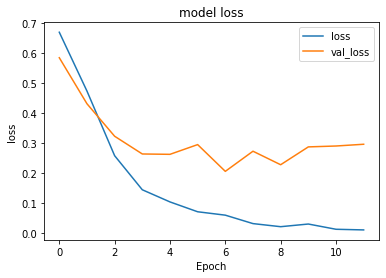

In [31]:
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("Epoch")
plt.legend(["loss","val_loss"])
plt.show()

In [32]:
from keras.models import load_model
saved_model = load_model("models/bilstm_approach#22.h5")

result = saved_model.evaluate(X_train,Y_train,
                               batch_size=128, #litterature review
                            verbose=True)


14/14 [==============================] - 3s 149ms/step - loss: 0.0333 - accuracy: 0.9938


In [33]:
print("train loss: %0.3f" % result[0])
print("train acc: %0.3f" % result[1])

train loss: 0.033
train acc: 0.994


In [34]:
result_val = saved_model.evaluate(X_val,Y_val,
                               batch_size=128, #litterature review
                            verbose=True)

3/3 [==============================] - 0s 132ms/step - loss: 0.2064 - accuracy: 0.9304


In [35]:
print("validation loss: %0.3f" % result_val[0])
print("validation acc: %0.3f" % result_val[1])

validation loss: 0.206
validation acc: 0.930


In [36]:
train_accuracy = "%.4f" % (result[1])
train_Loss = r"%.4f" % (result[0])
val_accuracy = "%.4f" % (result_val[1])
val_loss = "%.4f" % (result_val[0])

# 4. Predictions

### Test set

In [37]:
y_pred=saved_model.predict(X_test, batch_size=128, verbose=True)

5/5 [==============================] - 1s 129ms/step


In [38]:
print(y_pred)

[[1.2096825e-05 9.9998796e-01]
 [6.6442946e-05 9.9993360e-01]
 [3.5537690e-01 6.4462310e-01]
 ...
 [1.4115899e-05 9.9998593e-01]
 [2.1661177e-05 9.9997830e-01]
 [1.2518220e-05 9.9998748e-01]]


In [39]:
print(Y_train)

[[1. 0.]
 [0. 1.]
 [0. 1.]
 ...
 [0. 1.]
 [1. 0.]
 [0. 1.]]


In [40]:
print(Y_test)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 ...
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [41]:
print("\n Accuracy: %0.2f" % accuracy_score(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))
print("\n Confusion matrix\n")
print(classification_report(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))


 Accuracy: 0.92

 Confusion matrix

              precision    recall  f1-score   support

           0       0.97      0.87      0.92       263
           1       0.88      0.98      0.93       264

    accuracy                           0.92       527
   macro avg       0.93      0.92      0.92       527
weighted avg       0.93      0.92      0.92       527



In [42]:
y_pred=np.argmax(y_pred, axis=1)
Y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[229  34]
 [  6 258]]


In [43]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, y_pred))
test_recall  = "%.4f" % (recall_score(Y_test, y_pred))
test_F1_score  = "%.4f" % (f1_score(Y_test, y_pred))
test_precision  = "%.4f" % (precision_score(Y_test, y_pred))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.9241
recall :  0.9773
F1_score :  0.9281
precision :  0.8836


# 5. Save results to Excel file

In [44]:
# define tarjet
newFile = "../results_BiLSTM_set3.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #22', 2:train_accuracy, 3:train_Loss, 4:val_accuracy, 5:val_loss, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach#1
index = 24

# delete row of approach#1
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)